In [4]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Exercise 1

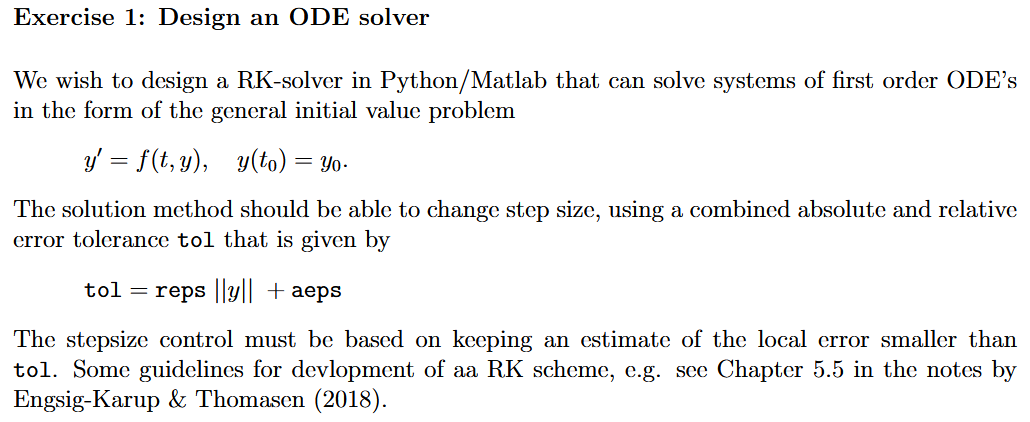

## Task a)

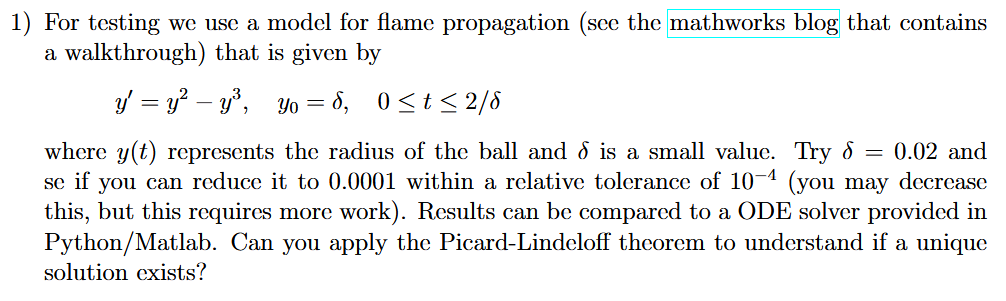

We test with the flame propagation model:
$$
y' = y^2 - y^3, \quad y_0 = \delta, \quad 0\leq t \leq 2/\delta
$$
Where y(t) is the radius of the ball of flame

### Testing scipys ODE solver

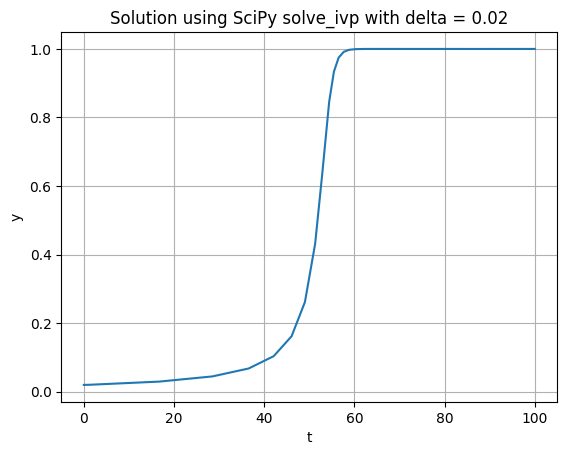

In [2]:
# Adapted to Python from MATLAB code from mathworks.com
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

delta = 0.02
F = lambda t, y: y**2 - y**3
sol = solve_ivp(F, [0, 2/delta], [delta], rtol=1e-4)

plt.plot(sol.t, sol.y[0])
plt.xlabel('t')
plt.ylabel('y')
plt.title('Solution using SciPy solve_ivp with delta = 0.02')
plt.grid()
plt.show()

### Implementing a RK23 ODE solver

In [49]:
# Implementation of a RK34 ODE solver for the flame model
def rk23(F, t_span, y0, reps=1e-4, aeps=1e-6):
    t0, tf = t_span
    t = t0
    y = y0
    dt = 0.1  # Initial time step
    times = [t]
    values = [y]
    while t < tf:
        if t + dt > tf:
            dt = tf - t
        xi1 = y
        xi2 = y + 1/2*dt*F(t, xi1)
        xi3 = y + (-1)*dt*F(t, xi1) + 2*dt*F(t + 1/2*dt, xi2)

        y_next = y + dt*(1/6*F(t, xi1) + 2/3*F(t + 1/2*dt, xi2) + 1/6*F(t + 1*dt, xi3))
        
        error = dt*(1/12*F(t, xi1) - 1/6*F(t + 1/2*dt, xi2) + 1/12*F(t+1*dt, xi3))

        tol = reps * np.abs(y) + aeps  # mixed relative/absolute tolerance
        if error < tol:
            t += dt
            y = y_next
            times.append(t)
            values.append(y)
        dt *= 0.9*(tol / error)**(1/4) if error > 0 else 1

    return np.array(times), np.array(values)

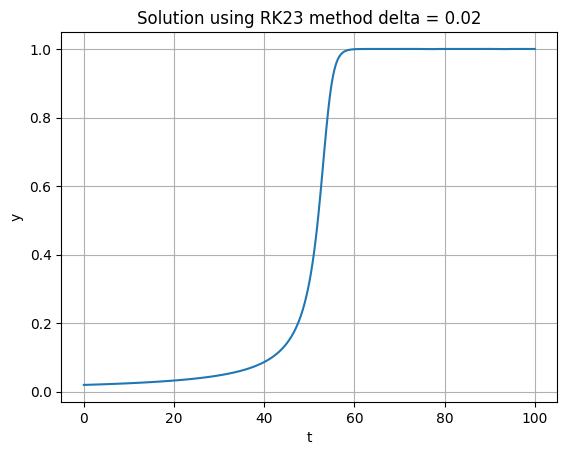

In [50]:
delta = 0.02
F = lambda t, y: y**2 - y**3
times, values = rk23(F, [0, 2/delta], delta)

plt.plot(times, values)
plt.xlabel('t')
plt.ylabel('y')
plt.title('Solution using RK23 method delta = 0.02')
plt.grid()
plt.show()

## Convergence test

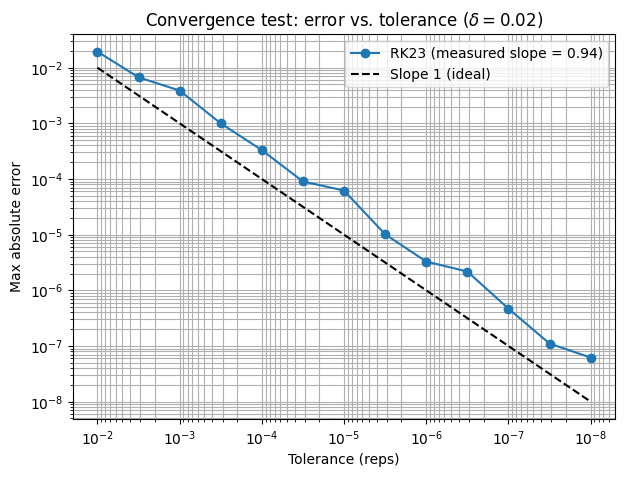

Estimated convergence rate (slope): 0.940  (expected ≈ 1.0)


In [51]:

# Convergence test for RK23
# For adaptive solvers, convergence is measured by varying the tolerance (reps).
# The global error should scale ~O(tol), giving a slope of 1 on a log-log plot.

delta = 0.02
F = lambda t, y: y**2 - y**3
t_span = [0, 2/delta]

# Reference solution
ref = solve_ivp(F, t_span, [delta], rtol=1e-12, atol=1e-14, dense_output=True)

tolerances = np.logspace(-2, -8, 13)  # reps from 1e-2 down to 1e-8
errors = []

for tol in tolerances:
    times, values = rk23(F, t_span, delta, reps=tol, aeps=tol * 1e-3)
    # Evaluate reference at the solver's own time points and take max error
    y_ref = ref.sol(times)[0]
    errors.append(np.max(np.abs(values - y_ref)))

errors = np.array(errors)

# Fit a line in log-log space to get the convergence rate
coeffs = np.polyfit(np.log10(tolerances), np.log10(errors), 1)
slope = coeffs[0]

plt.figure(figsize=(7, 5))
plt.loglog(tolerances, errors, 'C0o-', label=f'RK23 (measured slope = {slope:.2f})')
plt.loglog(tolerances, tolerances, 'k--', label='Slope 1 (ideal)')
plt.xlabel('Tolerance (reps)')
plt.ylabel('Max absolute error')
plt.title(rf'Convergence test: error vs. tolerance ($\delta={delta}$)')
plt.legend()
plt.grid(which='both')
plt.gca().invert_xaxis()  # tight tolerances on the right
plt.show()

print(f"Estimated convergence rate (slope): {slope:.3f}  (expected ≈ 1.0)")


### Comparison of rk23 and scipy ODE solver

Using different delta values we compare rk23 and scipy solver

Started with 0.02
Solved 0.02
Started with 0.01
Solved 0.01
Started with 0.005
Solved 0.005
Started with 0.0001
Solved 0.0001


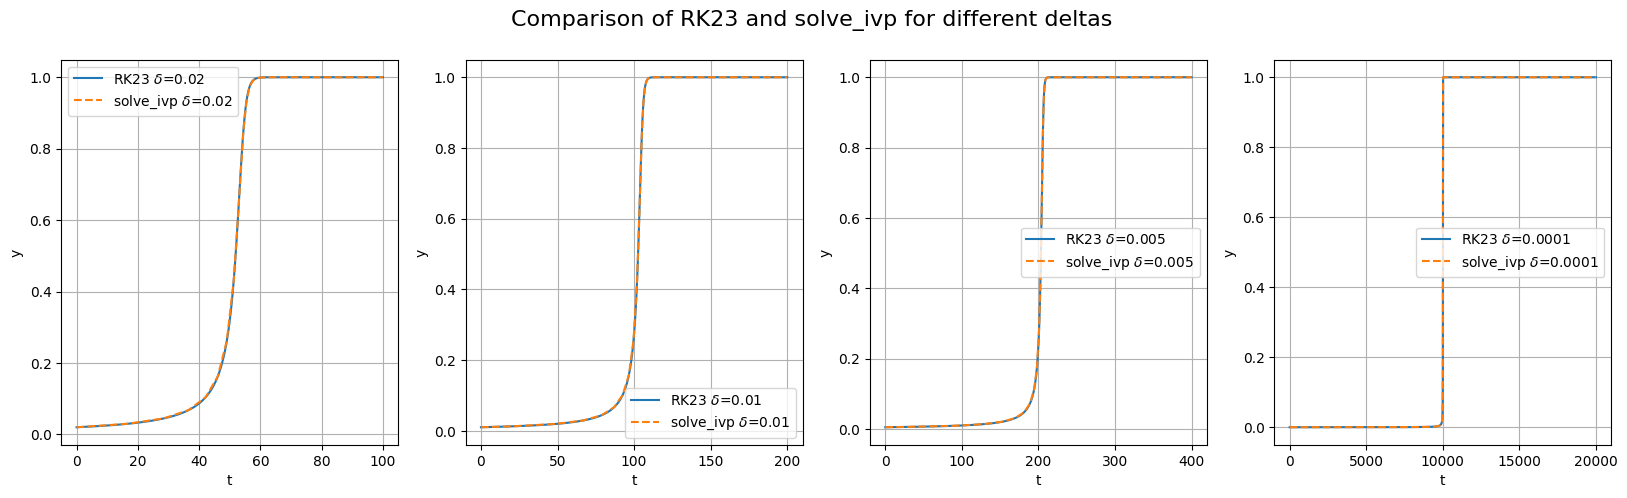

In [23]:
deltas = [0.02, 0.01, 0.005, 0.0001]
F = lambda t, y: y**2 - y**3

#subplotting the results for different deltas
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Comparison of RK23 and solve_ivp for different deltas', fontsize=16)

for i, delta in enumerate(deltas):
    print(f"Started with {delta}")
    times, values = rk23(F, [0, 2/delta], delta, reps = 1e-4, aeps = 1e-8)
    sol = solve_ivp(F, [0, 2/delta], [delta], rtol=1e-4)
    print(f"Solved {delta}")
    ax[i].plot(times, values, label=rf'RK23 $\delta$={delta}')
    ax[i].plot(sol.t, sol.y[0], '--', label=rf'solve_ivp $\delta$={delta}')
    ax[i].set_xlabel('t')
    ax[i].set_ylabel('y')
    ax[i].grid()
    ax[i].legend()
plt.show()

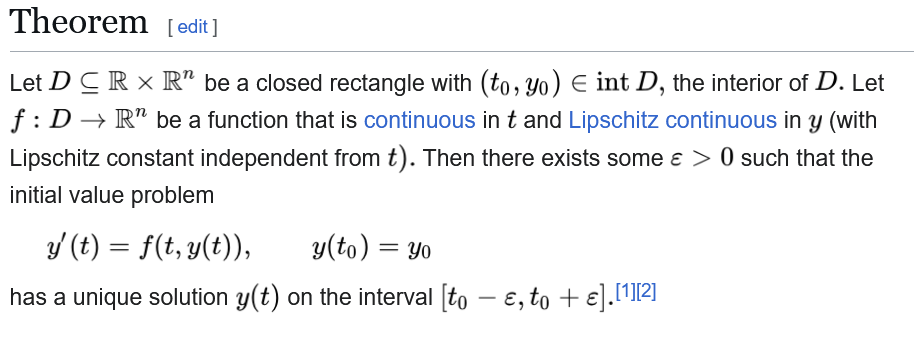
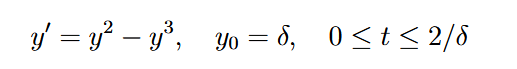

We check our $f(t,y)$ for continuity and Lipschitz condition. We see that it is continous everywhere for $(t_0, y_0) \in \mathbb{R}\times\mathbb{R}$, and also Lipschitz in y since $\frac{\partial f}{\partial y} = 2y - 3y^2$ is bounded around $(0, \delta)$. Therefore the Picard-Lindelöf theorem holds for this IVP, however we only look at half the interval, $[0, 2/\delta] \Rightarrow [0, \epsilon]$ but since we guaranteed uniqueness on the full intervald, uniqueness also holds on half the interval

## Task b)

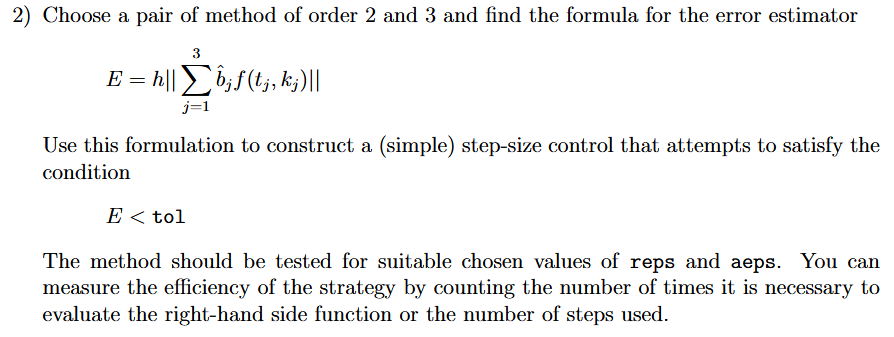

We currently have a 2nd order method, we want to estimate the errors using a 3rd order method. Thus we choose a new vector $\tilde{\textbf{b}}$ for an alternative computation of a 2nd order method, we do this by choosing $\tilde{b}_3 = 0$ and the rest of the coefficients are chosen from the order conditions. For these and the consistency requirement to be fulfilled we need:
$$
\begin{align*}
    \sum^r_{j=1} a_{ij} &= c_i \\
    \sum^r_{j=1} b_j &= 1\\
    \sum^r_{j=1} b_j c_j &= 1/2
\end{align*}
$$

With $\tilde{b}_3 = 0$, we choose $c_1 = 0$, $c_2 = 1/2$, $c_3 = 1$, which leads to
$$
b_1 0 + b_2 \frac12 + 0\cdot 1 = \frac12
$$
We choose $b_2 = 1$, now we choose our $a_{ij} = \frac12$, therefore the final butcher tableu becomes:
| 0 | 0 | | |
| --- | --- | --- | --- |
| 1/2 | 1/2 | 0 | | |
| 1 | 1/2 | 1/2 | 0 | |
| | 0 | 1 | 0 | 

The formula for the error then becomes:
$$
E = \tilde{y}_{n+1} - y_{n+1} = h\sum^3_{i=1} (\tilde{b}_i - b_i) f(t_i, \xi_i) = h((0-1/6)f(t_1, \xi_1) + (1-2/3)f(t_2, \xi_2) + (0-1/6)f(t_3, \xi_3))
$$

In [38]:

# Implementation of a RK23 ODE solver for the flame model
def rk23_adaptive(F, t_span, y0, reps=1e-4, aeps=1e-6):
    t0, tf = t_span
    t = t0
    y = y0
    dt = 0.1  # Initial time step
    times = [t]
    values = [y]
    steps = 0

    while t < tf:
        if t + dt > tf:
            dt = tf - t
        xi1 = y
        xi2 = y + 1/2*dt*F(t, xi1)
        xi3 = y + (-1)*dt*F(t, xi1) + 2*dt*F(t + 1/2*dt, xi2)

        # Implementing the error estimation step size control
        y_next = y + dt*(1/6*F(t, xi1) + 2/3*F(t + 1/2*dt, xi2) + 1/6*F(t + 1*dt, xi3))
        y_next_tilde = y + dt*(0*F(t, xi1) + 1*F(t + 1/2*dt, xi2))

        error = np.abs(y_next_tilde - y_next)

        tol = reps * np.abs(y) + aeps  # mixed relative/absolute tolerance
        if error < tol:
            steps += 1
            t += dt
            y = y_next
            times.append(t)
            values.append(y)
        dt *= 0.9*(tol / error)**(1/4) if error > 0 else 2.0

    return np.array(times), np.array(values), steps


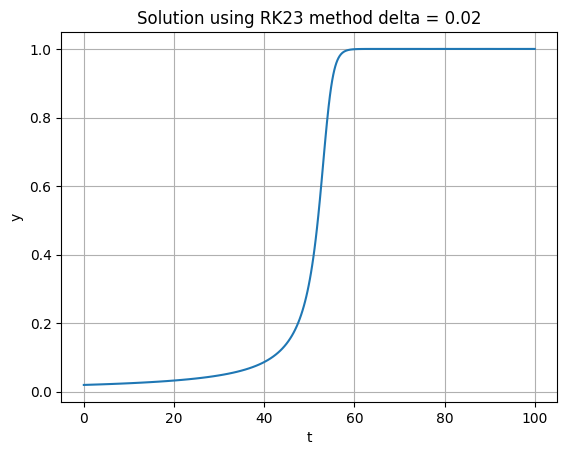

In [39]:
delta = 0.02
F = lambda t, y: y**2 - y**3
times, values, steps = rk23_adaptive(F, [0, 2/delta], delta)

plt.plot(times, values)
plt.xlabel('t')
plt.ylabel('y')
plt.title('Solution using RK23 method delta = 0.02')
plt.grid()
plt.show()

## Convergence test

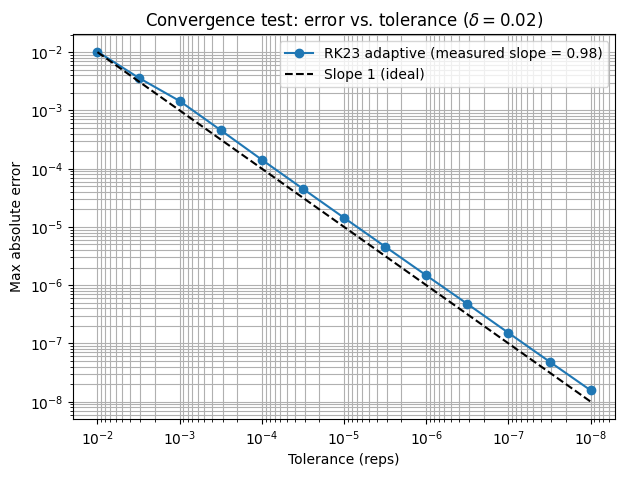

Estimated convergence rate (slope): 0.979  (expected ≈ 1.0)


In [55]:

# Convergence test for RK23
# For adaptive solvers, convergence is measured by varying the tolerance (reps).
# The global error should scale ~O(tol), giving a slope of 1 on a log-log plot.

delta = 0.02
F = lambda t, y: y**2 - y**3
t_span = [0, 2/delta]

# Reference solution
ref = solve_ivp(F, t_span, [delta], rtol=1e-12, atol=1e-14, dense_output=True)

tolerances = np.logspace(-2, -8, 13)  # reps from 1e-2 down to 1e-8
errors = []

for tol in tolerances:
    times, values, _ = rk23_adaptive(F, t_span, delta, reps=tol, aeps=tol * 1e-3)
    # Evaluate reference at the solver's own time points and take max error
    y_ref = ref.sol(times)[0]
    errors.append(np.max(np.abs(values - y_ref)))

errors = np.array(errors)

# Fit a line in log-log space to get the convergence rate
coeffs = np.polyfit(np.log10(tolerances), np.log10(errors), 1)
slope = coeffs[0]

plt.figure(figsize=(7, 5))
plt.loglog(tolerances, errors, 'C0o-', label=f'RK23 adaptive (measured slope = {slope:.2f})')
plt.loglog(tolerances, tolerances, 'k--', label='Slope 1 (ideal)')
plt.xlabel('Tolerance (reps)')
plt.ylabel('Max absolute error')
plt.title(rf'Convergence test: error vs. tolerance ($\delta={delta}$)')
plt.legend()
plt.grid(which='both')
plt.gca().invert_xaxis()  # tight tolerances on the right
plt.show()

print(f"Estimated convergence rate (slope): {slope:.3f}  (expected ≈ 1.0)")


In [41]:
delta = 0.0001
F = lambda t, y: y**2 - y**3
steps_rk23 = []
steps_rk23_adaptive = []
for _ in range(5):
    times, values, steps = rk23(F, [0, 2/delta], delta)
    steps_rk23.append(steps)
    times_a, values_a, steps_a = rk23_adaptive(F, [0, 2/delta], delta)
    steps_rk23_adaptive.append(steps_a)

print(f"Average steps for RK23: {np.mean(steps_rk23)}")
print(f"Average steps for RK23 adaptive: {np.mean(steps_rk23_adaptive)}")

Average steps for RK23: 6419.0
Average steps for RK23 adaptive: 4086.0


RK23          — max abs error: 1.23e-03,  mean abs error: 6.41e-05,  steps: 87
RK23 adaptive — max abs error: 8.50e-04,  mean abs error: 3.05e-05,  steps: 106


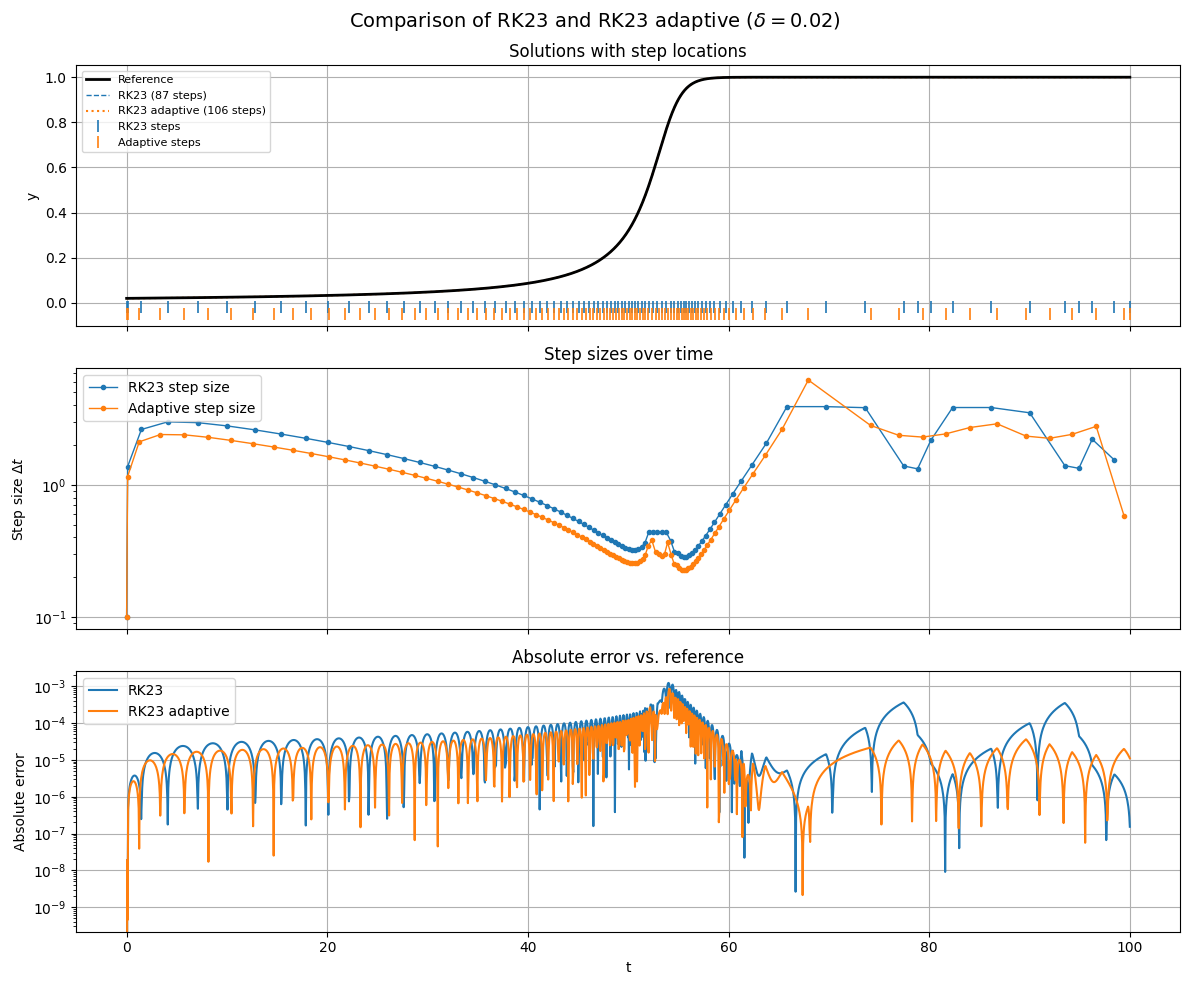

In [46]:

# Accuracy comparison: interpolate RK23 solutions onto the reference grid and compute max absolute error
delta = 0.02
F = lambda t, y: y**2 - y**3
t_span = [0, 2/delta]

# Reference solution with very tight tolerances
ref = solve_ivp(F, t_span, [delta], rtol=1e-10, atol=1e-12, dense_output=True)

t_eval = np.linspace(t_span[0], t_span[1], 2000)
y_ref = ref.sol(t_eval)[0]

# RK23 solutions
times_rk23, values_rk23, _ = rk23(F, t_span, delta)
times_adap, values_adap, _ = rk23_adaptive(F, t_span, delta)

# Interpolate onto t_eval for error comparison
y_rk23_interp = np.interp(t_eval, times_rk23, values_rk23)
y_adap_interp = np.interp(t_eval, times_adap, values_adap)

err_rk23 = np.abs(y_rk23_interp - y_ref)
err_adap = np.abs(y_adap_interp - y_ref)

print(f"RK23          — max abs error: {np.max(err_rk23):.2e},  mean abs error: {np.mean(err_rk23):.2e},  steps: {len(times_rk23)-1}")
print(f"RK23 adaptive — max abs error: {np.max(err_adap):.2e},  mean abs error: {np.mean(err_adap):.2e},  steps: {len(times_adap)-1}")

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle(rf'Comparison of RK23 and RK23 adaptive ($\delta={delta}$)', fontsize=14)

# --- Row 1: solutions with rug plot of step locations ---
axes[0].plot(t_eval, y_ref, 'k-', linewidth=2, label='Reference', zorder=3)
axes[0].plot(times_rk23, values_rk23, 'C0--', linewidth=1, label=f'RK23 ({len(times_rk23)-1} steps)', zorder=2)
axes[0].plot(times_adap, values_adap, 'C1:', linewidth=1.5, label=f'RK23 adaptive ({len(times_adap)-1} steps)', zorder=2)
axes[0].plot(times_rk23, np.full_like(times_rk23, -0.02), '|', color='C0', markersize=8, markeredgewidth=1.2, label='RK23 steps')
axes[0].plot(times_adap, np.full_like(times_adap, -0.05), '|', color='C1', markersize=8, markeredgewidth=1.2, label='Adaptive steps')
axes[0].set_ylabel('y')
axes[0].set_title('Solutions with step locations')
axes[0].legend(fontsize=8); axes[0].grid()

# --- Row 2: step sizes over time ---
dt_rk23 = np.diff(times_rk23)
dt_adap = np.diff(times_adap)
axes[1].semilogy(times_rk23[:-1], dt_rk23, 'C0o-', markersize=3, linewidth=1, label='RK23 step size')
axes[1].semilogy(times_adap[:-1], dt_adap, 'C1o-', markersize=3, linewidth=1, label='Adaptive step size')
axes[1].set_ylabel('Step size $\\Delta t$')
axes[1].set_title('Step sizes over time')
axes[1].legend(); axes[1].grid()

# --- Row 3: absolute error ---
axes[2].semilogy(t_eval, err_rk23, 'C0', label='RK23')
axes[2].semilogy(t_eval, err_adap, 'C1', label='RK23 adaptive')
axes[2].set_xlabel('t')
axes[2].set_ylabel('Absolute error')
axes[2].set_title('Absolute error vs. reference')
axes[2].legend(); axes[2].grid()

plt.tight_layout()
plt.show()
